In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
from numpy.ma.core import negative

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [5]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 28, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 10})
plt.rcParams.update({"axes.prop_cycle": plt.cycler("color", ["royalblue", "tomato", "forestgreen", "darkgoldenrod", "darkorchid"])})

In [6]:
exp_list = ["glori","m6ace","miclip2","sac"]
exp_dict = {}
exp_path = "/extdata3/baeklab/Jungmin/RNAmod/valid.new/cmp/{exp}.txt"
for exp in exp_list:
    df = pd.read_csv(exp_path.format(exp=exp), sep="\t")
    df["genome_id"] = df["chr"] + ":" + df["str"].astype(str) + ":" + df["pos"].astype(str)
    if "qval_neg" in df.columns:
        df["m6a"] = (df["qval"] < 1E-7) & ~(df["qval_neg"] < 0.1)
    else:
        df["m6a"] = df["qval"] < 1E-7
    exp_dict[exp] = df
for exp in ["m6ace","miclip2","sac"]:
    df = exp_dict[exp]
    df = df.rename(columns={"m6a": f"label_{exp}", "depth": f"depth_{exp}", "qval": f"q_{exp}"})
    df = df[["genome_id", f"label_{exp}", f"depth_{exp}", f"q_{exp}"]].copy()
    exp_dict[exp] = df
for exp in ["glori"]:
    df = exp_dict[exp]
    df = df.rename(columns={"m6a": f"label_{exp}", "depth": f"depth_{exp}", "dom": f"dom_{exp}", "qval": f"q_{exp}"})
    df = df[["genome_id", f"label_{exp}", f"depth_{exp}", f"dom_{exp}", f"q_{exp}"]].copy()
    exp_dict[exp] = df
for exp in exp_list:
    df = exp_dict[exp]
    df = df.set_index("genome_id", drop=True)
    exp_dict[exp] = df

label_df = pd.concat(exp_dict.values(), axis=1).reset_index()
label_df["label_glori_alt"] = (label_df["dom_glori"] >= 0.1) * label_df["label_glori"]
print(label_df)


                genome_id label_glori  depth_glori  dom_glori   q_glori  \
0            chr1:+:14120       False          1.0        NaN  0.129512   
1            chr1:+:63441       False          1.0        NaN  0.137144   
2           chr1:+:183817       False          3.0        NaN  0.016432   
3           chr1:+:184515       False          2.0        NaN  0.381221   
4           chr1:+:184761       False          1.0        NaN  0.194671   
...                   ...         ...          ...        ...       ...   
12206697  chrY:-:57015831         NaN          NaN        NaN       NaN   
12206698  chrY:-:57015855         NaN          NaN        NaN       NaN   
12206699  chrY:-:57015886         NaN          NaN        NaN       NaN   
12206700  chrY:-:57015896         NaN          NaN        NaN       NaN   
12206701  chrY:-:57015923         NaN          NaN        NaN       NaN   

         label_m6ace  depth_m6ace  q_m6ace label_miclip2  depth_miclip2  \
0                NaN    

In [7]:
label_df["label_alt"] = label_df[["label_glori_alt", "label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)

In [49]:
import venn, upsetplot

In [19]:
m6a_df = label_df[label_df["label_alt"]>0].copy()
print(m6a_df)

                genome_id label_glori  depth_glori  dom_glori   q_glori  \
25          chr1:+:629086       False        328.0        NaN  1.000000   
32          chr1:+:629116       False        211.0        NaN  1.000000   
36          chr1:+:629155       False         48.0        NaN  1.000000   
64          chr1:+:629312       False        125.0        NaN  1.000000   
66          chr1:+:629323       False        123.0        NaN  0.582331   
...                   ...         ...          ...        ...       ...   
12206621  chrY:-:11178762         NaN          NaN        NaN       NaN   
12206628  chrY:-:11206426         NaN          NaN        NaN       NaN   
12206629  chrY:-:11206438         NaN          NaN        NaN       NaN   
12206630  chrY:-:11206448         NaN          NaN        NaN       NaN   
12206659  chrY:-:18992579         NaN          NaN        NaN       NaN   

         label_m6ace  depth_m6ace  q_m6ace label_miclip2  depth_miclip2  \
25               NaN    

In [20]:
category_name_dict = {"label_glori_alt": "GLORI",
                      "label_sac": "SAC-seq",
                      "label_miclip2": "miCLIP2",
                      "label_m6ace": "m6ACE"}

In [23]:
venn_dict = {v:set(m6a_df[m6a_df[k]==True]["genome_id"].values) for k, v in category_name_dict.items()}

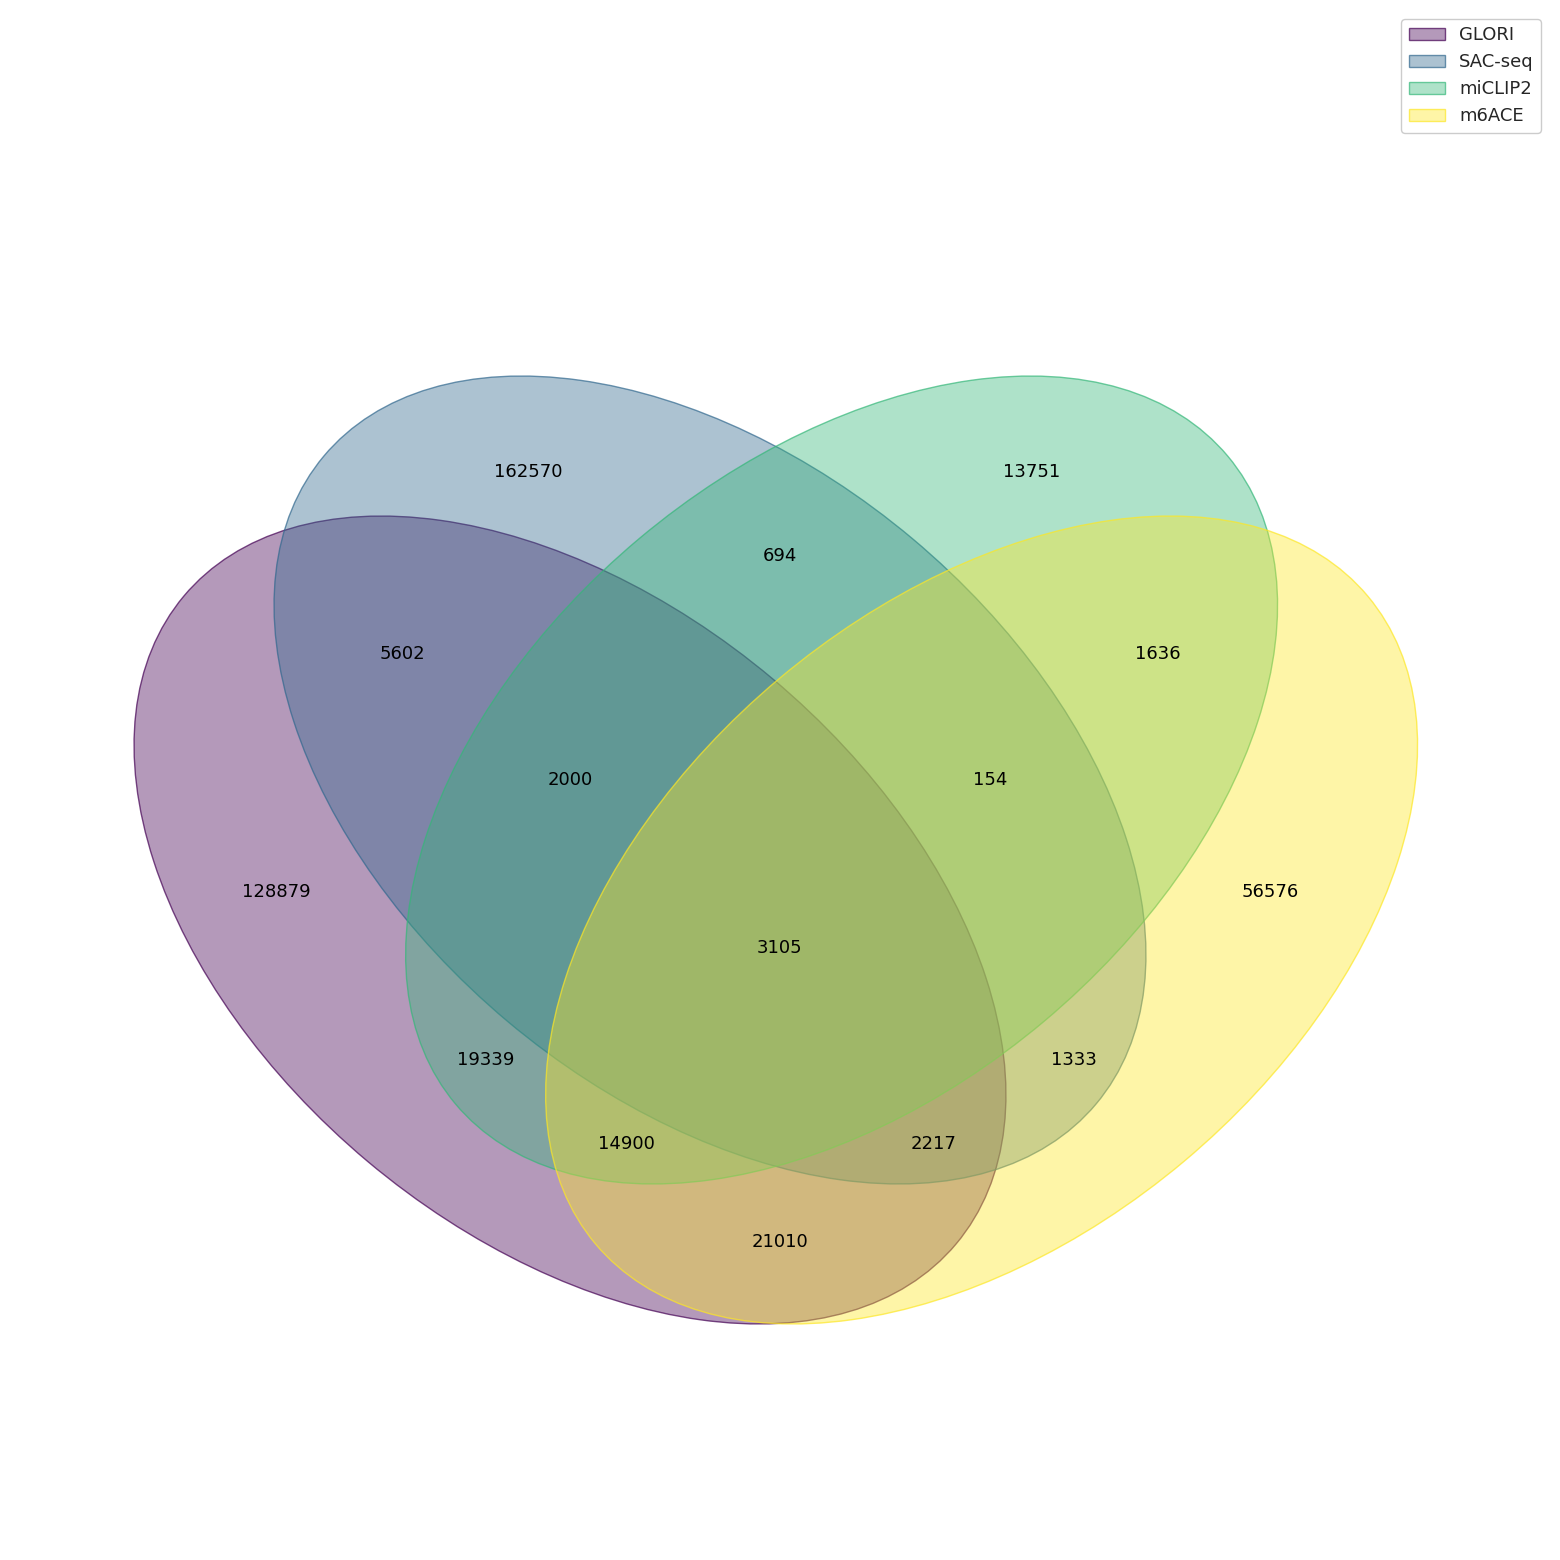

In [24]:
## Plot venn

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
venn.venn(venn_dict, ax=ax, legend_loc="upper left")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/analyses/venn_4exp.pdf")
plt.show()

In [74]:

indicators = {v: (m6a_df[k].values ==True) for k, v in category_name_dict.items()}
indicators = pd.DataFrame(indicators)


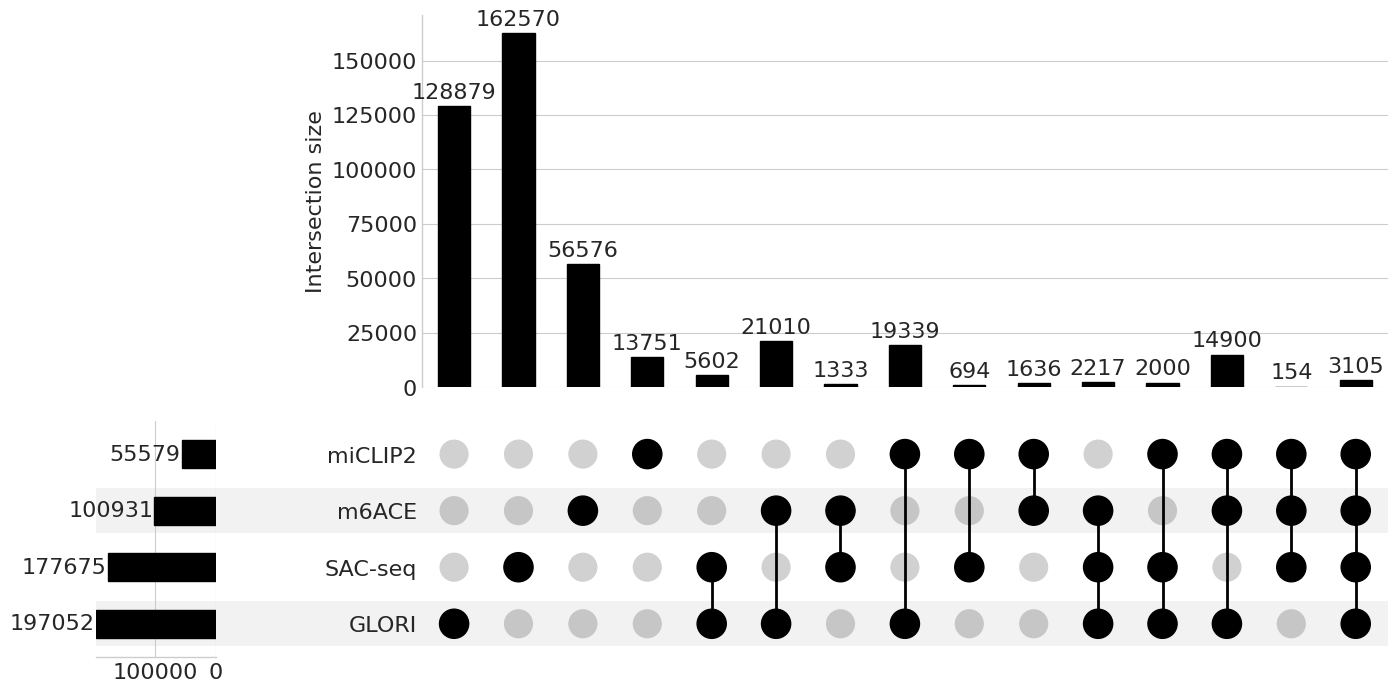

In [96]:
plt.rcParams.update({'font.size': 16, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
upsetplot.plot(upsetplot.from_indicators(indicators.copy()), subset_size="count", orientation="horizontal", show_counts=True, element_size=60, facecolor="black")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/analyses/upset_4exp.pdf")


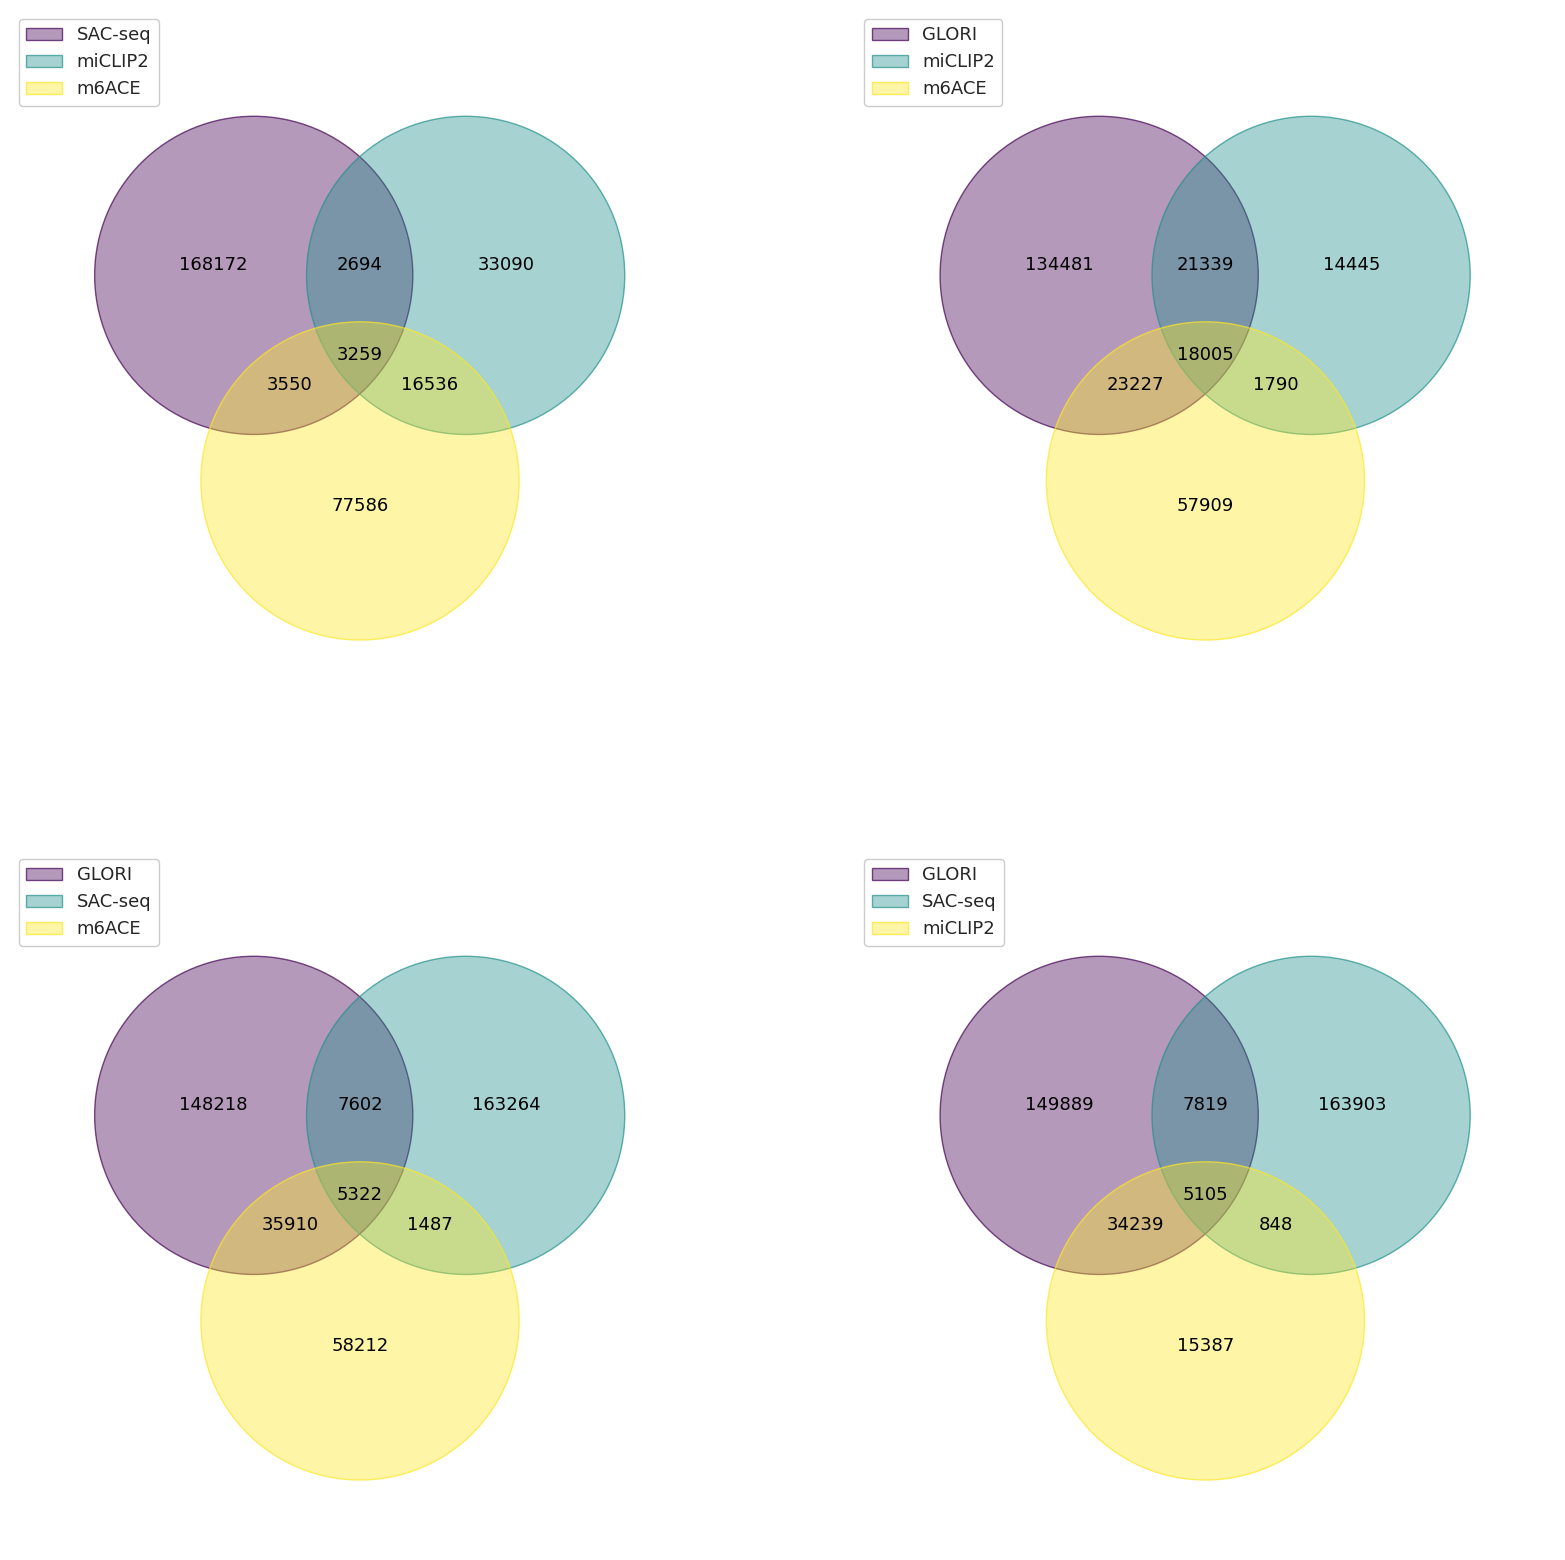

In [107]:
## Plot venn for set of 3 experiments, four times
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()
venn_dict = {v:set(m6a_df[m6a_df[k]==True]["genome_id"].values) for k, v in category_name_dict.items()}
for i, (k, v) in enumerate(category_name_dict.items()):
    ax = axes[i]
    venn_dict_temp = {x:y for x, y in venn_dict.items() if x != v}
    venn.venn(venn_dict_temp, ax=ax, legend_loc="upper left")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/analyses/venn_3exp.pdf")
plt.show()